# Phenotype And Genotype Exploration

This notebook keeps the exploration simple and local to the notebook.

Flow:

- configure notebook settings and paths
- load raw phenotype and genotype data
- restrict both tables to the shared `BioSample` cohort first
- clean and summarize phenotype data
- inspect genotype measurement methods and collapse duplicated gene-element records


In [133]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', None)


In [134]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()

PHENOTYPE_PATH = PROJECT_ROOT / 'data' / 'phenotype.tsv'
GENOTYPE_PATH = PROJECT_ROOT / 'data' / 'genotype.tsv'
ANTIBIOTIC_GROUP_PATH = PROJECT_ROOT / 'Antibiotic-Group.md'

MIN_ANTIBIOTIC_ROWS = 500
MIN_CLASS_COUNT = 100

# Lower MIC means smaller numeric MIC first.
# For equal numeric MIC values, this order keeps the stricter lower-bound interpretation first.
MEASUREMENT_ORDER_FOR_LOWEST = {'<': 0, '<=': 1, '==': 2, '>=': 3, '>': 4}


In [135]:
def load_raw_phenotype(path: Path) -> pd.DataFrame:
    phenotype = pd.read_csv(
        path,
        sep='\t',
        usecols=['#BioSample', 'Antibiotic', 'Measurement sign', 'MIC (mg/L)', 'Resistance phenotype'],
        dtype={'#BioSample': 'string', 'Antibiotic': 'string', 'Measurement sign': 'string', 'Resistance phenotype': 'string'},
    ).rename(columns={'#BioSample': 'BioSample'})
    phenotype['Measurement sign'] = phenotype['Measurement sign'].str.strip()
    phenotype['Resistance phenotype'] = phenotype['Resistance phenotype'].str.strip().str.lower()
    return phenotype


def clean_phenotype(phenotype: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:
    key_columns = ['BioSample', 'Antibiotic']
    working = phenotype.dropna(subset=['BioSample', 'Antibiotic', 'Resistance phenotype', 'MIC (mg/L)', 'Measurement sign']).copy()
    working = working[working['Resistance phenotype'].isin(['susceptible', 'resistant'])].copy()
    rows_after_basic_filter = int(len(working))

    label_counts = (
        working.groupby(key_columns, observed=True)['Resistance phenotype']
        .nunique()
        .rename('n_labels')
        .reset_index()
    )
    conflicting_pairs = label_counts[label_counts['n_labels'] > 1][key_columns].copy()
    conflicting_rows_removed = int(
        working.merge(conflicting_pairs.assign(_drop=1), on=key_columns, how='inner').shape[0]
    )

    if not conflicting_pairs.empty:
        working = working.merge(conflicting_pairs.assign(_drop=1), on=key_columns, how='left')
        working = working[working['_drop'].isna()].drop(columns='_drop')

    working['MIC (mg/L)'] = pd.to_numeric(working['MIC (mg/L)'], errors='coerce')
    working = working.dropna(subset=['MIC (mg/L)']).copy()
    working['measurement_rank_for_lowest'] = working['Measurement sign'].map(MEASUREMENT_ORDER_FOR_LOWEST)
    working = working.dropna(subset=['measurement_rank_for_lowest']).copy()
    working['measurement_rank_for_lowest'] = working['measurement_rank_for_lowest'].astype('int64')

    before_dedup_rows = len(working)
    working = working.sort_values(key_columns + ['MIC (mg/L)', 'measurement_rank_for_lowest'])
    cleaned = working.drop_duplicates(subset=key_columns, keep='first').copy()
    duplicate_rows_removed = int(before_dedup_rows - len(cleaned))
    cleaned['label'] = cleaned['Resistance phenotype'].map({'susceptible': 0, 'resistant': 1}).astype('uint8')

    stats = {
        'phenotype_rows_before_pair_cleanup': int(len(phenotype)),
        'phenotype_unique_isolates_before_pair_cleanup': int(phenotype['BioSample'].nunique()),
        'rows_after_basic_filter': rows_after_basic_filter,
        'conflicting_pairs_removed': int(len(conflicting_pairs)),
        'conflicting_rows_removed': conflicting_rows_removed,
        'rows_after_conflict_filter': int(before_dedup_rows),
        'duplicate_rows_removed_after_lowest_mic': duplicate_rows_removed,
        'clean_rows': int(len(cleaned)),
        'clean_unique_isolates': int(cleaned['BioSample'].nunique()),
    }
    return cleaned, stats


def summarize_phenotype_antibiotics(phenotype: pd.DataFrame) -> pd.DataFrame:
    summary = (
        phenotype.groupby('Antibiotic', observed=True)['label']
        .agg(n_records='count', n_resistant='sum')
        .reset_index()
    )
    summary['n_records'] = summary['n_records'].astype('int64')
    summary['n_resistant'] = summary['n_resistant'].astype('int64')
    summary['n_susceptible'] = (summary['n_records'] - summary['n_resistant']).astype('int64')
    summary['resistant_fraction'] = summary['n_resistant'] / summary['n_records']
    summary['eligible_for_model'] = (
        (summary['n_records'] >= MIN_ANTIBIOTIC_ROWS)
        & (summary['n_susceptible'] >= MIN_CLASS_COUNT)
        & (summary['n_resistant'] >= MIN_CLASS_COUNT)
    )
    return summary.sort_values(['n_records', 'Antibiotic'], ascending=[False, True]).reset_index(drop=True)


In [136]:
def filter_to_shared_isolates(phenotype: pd.DataFrame, genotype: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int]]:
    phenotype_isolates = set(phenotype['BioSample'].dropna().unique().tolist())
    genotype_isolates = set(genotype['BioSample'].dropna().unique().tolist())
    shared_isolates = phenotype_isolates & genotype_isolates

    phenotype_shared = phenotype[phenotype['BioSample'].isin(shared_isolates)].copy()
    genotype_shared = genotype[genotype['BioSample'].isin(shared_isolates)].copy()

    stats = {
        'raw_phenotype_rows': int(len(phenotype)),
        'raw_phenotype_unique_isolates': int(phenotype['BioSample'].nunique()),
        'raw_genotype_rows': int(len(genotype)),
        'raw_genotype_unique_isolates': int(genotype['BioSample'].nunique()),
        'shared_unique_isolates': int(len(shared_isolates)),
        'phenotype_rows_after_shared_isolate_filter': int(len(phenotype_shared)),
        'genotype_rows_after_shared_isolate_filter': int(len(genotype_shared)),
    }
    return phenotype_shared, genotype_shared, stats


## Raw Data


In [137]:
raw_phenotype = load_raw_phenotype(PHENOTYPE_PATH)
raw_genotype = pd.read_csv(
    GENOTYPE_PATH,
    sep='\t',
    usecols=['#BioSample', 'Element symbol', 'Subtype', 'Class', 'Subclass', 'Method', '% Coverage of reference', '% Identity to reference'],
    dtype={
        '#BioSample': 'string',
        'Element symbol': 'string',
        'Subtype': 'string',
        'Class': 'string',
        'Subclass': 'string',
        'Method': 'string',
    },
).rename(columns={'#BioSample': 'BioSample'})

shared_phenotype, shared_genotype, shared_isolate_stats = filter_to_shared_isolates(raw_phenotype, raw_genotype)
shared_stats_df = pd.DataFrame({'metric': list(shared_isolate_stats.keys()), 'value': list(shared_isolate_stats.values())})
display(shared_stats_df)


,metric,value
0,raw_phenotype_rows,135989
1,raw_phenotype_unique_isolates,9623
2,raw_genotype_rows,1660165
3,raw_genotype_unique_isolates,227611
4,shared_unique_isolates,6813
5,phenotype_rows_after_shared_isolate_filter,95949
6,genotype_rows_after_shared_isolate_filter,46728


## Phenotype


In [138]:
def parse_antibiotic_groups(path: Path) -> pd.DataFrame:
    lines = [line.rstrip('\n') for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]
    nodes = []
    for line in lines:
        indent = len(line) - len(line.lstrip(' '))
        level = indent // 2
        nodes.append({'level': level, 'label': line.strip()})

    stack = []
    records = []

    for index, node in enumerate(nodes):
        level = int(node['level'])
        label = str(node['label'])
        stack = stack[:level]
        stack.append(label)

        next_level = int(nodes[index + 1]['level']) if index + 1 < len(nodes) else -1
        if next_level > level:
            continue

        if level == 0:
            group = label
            subgroup = ''
        elif level == 1:
            group = stack[0]
            subgroup = ''
        else:
            group = stack[0]
            subgroup = stack[1]

        records.append(
            {
                'Antibiotic': label,
                'Antibiotic group': group,
                'Antibiotic subgroup': subgroup,
                'Antibiotic path': ' > '.join(stack[:-1]) if len(stack) > 1 else label,
            }
        )

    return pd.DataFrame(records).sort_values(['Antibiotic group', 'Antibiotic']).reset_index(drop=True)


def attach_antibiotic_groups(summary: pd.DataFrame, groups: pd.DataFrame) -> pd.DataFrame:
    merged = summary.merge(groups, on='Antibiotic', how='left')
    merged['Antibiotic group'] = merged['Antibiotic group'].fillna(merged['Antibiotic'])
    merged['Antibiotic subgroup'] = merged['Antibiotic subgroup'].fillna('')
    merged['Antibiotic path'] = merged['Antibiotic path'].fillna(merged['Antibiotic'])
    return merged.sort_values(['Antibiotic group', 'Antibiotic subgroup', 'Antibiotic'], na_position='last').reset_index(drop=True)


def format_grouped_table(frame: pd.DataFrame, group_col: str, subgroup_col: str) -> pd.DataFrame:
    display_frame = frame.copy()
    repeated_group = display_frame[group_col].eq(display_frame[group_col].shift())
    display_frame.loc[repeated_group, group_col] = ''

    repeated_subgroup = (
        display_frame[subgroup_col].eq(display_frame[subgroup_col].shift())
        & display_frame[group_col].eq('')
    )
    display_frame.loc[repeated_subgroup, subgroup_col] = ''
    return display_frame.reset_index(drop=True)


def summarize_numeric_values(series: pd.Series, max_unique_to_list: int = 10) -> str:
    values = sorted(pd.Series(series).dropna().astype(float).unique().tolist())
    if not values:
        return ''
    if len(values) <= max_unique_to_list:
        return ', '.join(f'{value:.2f}' for value in values)
    return f'{values[0]:.2f} to {values[-1]:.2f} ({len(values)} unique values)'


In [139]:
antibiotic_groups = parse_antibiotic_groups(ANTIBIOTIC_GROUP_PATH)
clean_phenotype_df, phenotype_cleaning_stats = clean_phenotype(shared_phenotype)
phenotype_stats_df = pd.DataFrame({'metric': list(phenotype_cleaning_stats.keys()), 'value': list(phenotype_cleaning_stats.values())})
display(phenotype_stats_df)


,metric,value
0,phenotype_rows_before_pair_cleanup,95949
1,phenotype_unique_isolates_before_pair_cleanup,6813
2,rows_after_basic_filter,95926
3,conflicting_pairs_removed,1
4,conflicting_rows_removed,2
5,rows_after_conflict_filter,95924
6,duplicate_rows_removed_after_lowest_mic,33
7,clean_rows,95891
8,clean_unique_isolates,6813


In [140]:
phenotype_summary_before_threshold = attach_antibiotic_groups(
    summarize_phenotype_antibiotics(clean_phenotype_df),
    antibiotic_groups,
)
display(
    format_grouped_table(
        phenotype_summary_before_threshold[
            [
                'Antibiotic group', 'Antibiotic subgroup', 'Antibiotic',
                'n_records', 'n_susceptible', 'n_resistant', 'resistant_fraction', 'eligible_for_model'
            ]
        ],
        group_col='Antibiotic group',
        subgroup_col='Antibiotic subgroup',
    )
)

,Antibiotic group,Antibiotic subgroup,Antibiotic,n_records,n_susceptible,n_resistant,resistant_fraction,eligible_for_model
0,aminoglycosides,,amikacin,2043,2039,4,0.001958,False
1,,,gentamicin,6459,5575,884,0.136863,True
2,,,kanamycin,2772,2304,468,0.168831,True
3,,,streptomycin,6050,2850,3200,0.528926,True
4,,,tobramycin,7,3,4,0.571429,False
5,beta-lactams,carbapenems,doripenem,5,4,1,0.200000,False
6,,,ertapenem,7,6,1,0.142857,False
7,,,imipenem,6,5,1,0.166667,False
8,,,meropenem,3231,3230,1,0.000310,False
9,,cephalosporins,cefazolin,7,1,6,0.857143,False


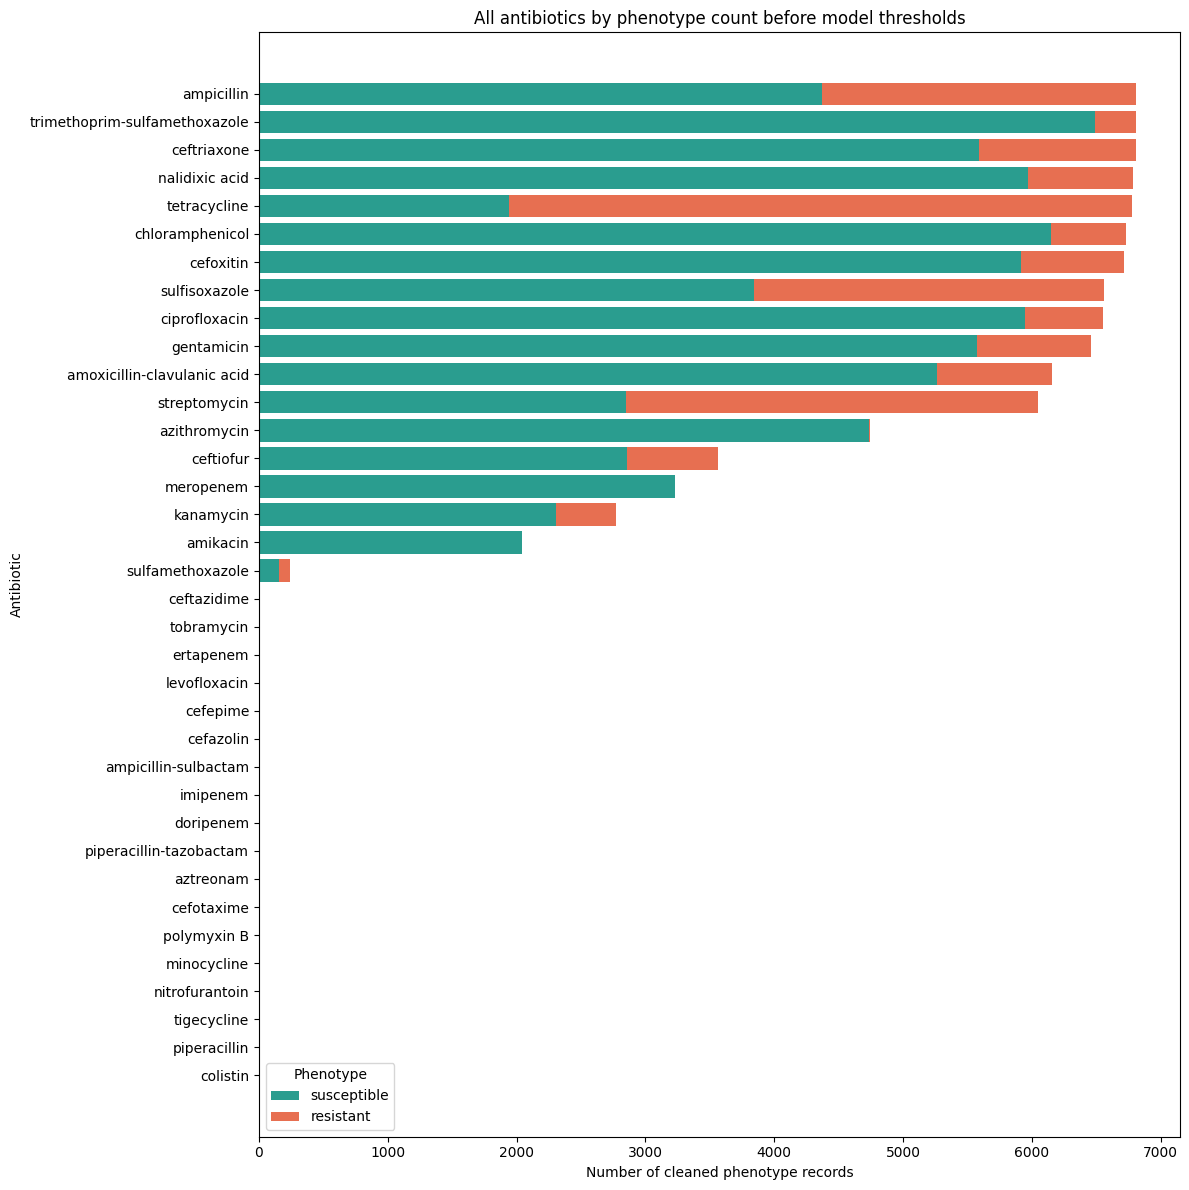

In [141]:
plot_df = phenotype_summary_before_threshold.sort_values('n_records', ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, 12))
ax.barh(plot_df['Antibiotic'], plot_df['n_susceptible'], color='#2a9d8f', label='susceptible')
ax.barh(plot_df['Antibiotic'], plot_df['n_resistant'], left=plot_df['n_susceptible'], color='#e76f51', label='resistant')
ax.set_title('All antibiotics by phenotype count before model thresholds')
ax.set_xlabel('Number of cleaned phenotype records')
ax.set_ylabel('Antibiotic')
ax.legend(title='Phenotype')
plt.tight_layout()

In [142]:
phenotype_summary_after_threshold = phenotype_summary_before_threshold[
    phenotype_summary_before_threshold['eligible_for_model']
].copy()
display(
    format_grouped_table(
        phenotype_summary_after_threshold[
            [
                'Antibiotic group', 'Antibiotic subgroup', 'Antibiotic',
                'n_records', 'n_susceptible', 'n_resistant', 'resistant_fraction'
            ]
        ],
        group_col='Antibiotic group',
        subgroup_col='Antibiotic subgroup',
    )
)

,Antibiotic group,Antibiotic subgroup,Antibiotic,n_records,n_susceptible,n_resistant,resistant_fraction
0,aminoglycosides,,gentamicin,6459,5575,884,0.136863
1,,,kanamycin,2772,2304,468,0.168831
2,,,streptomycin,6050,2850,3200,0.528926
3,beta-lactams,cephalosporins,cefoxitin,6715,5917,798,0.118838
4,,,ceftiofur,3562,2854,708,0.198765
5,,,ceftriaxone,6807,5594,1213,0.178199
6,,penicillins,amoxicillin-clavulanic acid,6159,5262,897,0.145641
7,,,ampicillin,6810,4370,2440,0.358297
8,phenicols,,chloramphenicol,6730,6146,584,0.086776
9,quinolones,,nalidixic acid,6789,5974,815,0.120047


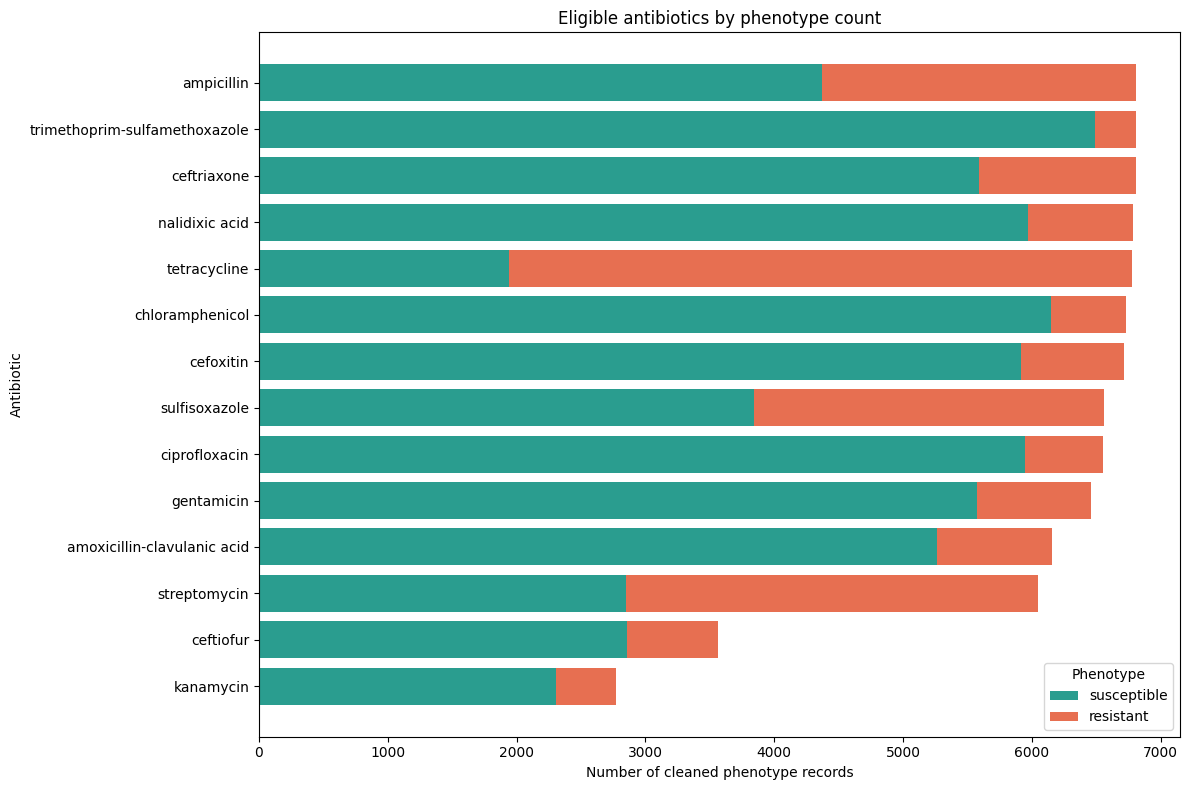

In [143]:
plot_df = phenotype_summary_after_threshold.sort_values('n_records', ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(plot_df['Antibiotic'], plot_df['n_susceptible'], color='#2a9d8f', label='susceptible')
ax.barh(plot_df['Antibiotic'], plot_df['n_resistant'], left=plot_df['n_susceptible'], color='#e76f51', label='resistant')
ax.set_title('Eligible antibiotics by phenotype count')
ax.set_xlabel('Number of cleaned phenotype records')
ax.set_ylabel('Antibiotic')
ax.legend(title='Phenotype')
plt.tight_layout()

## Genotype

In [144]:
METHOD_FAMILY_PRIORITY = {
    'EXACT': 0,
    'ALLELE': 1,
    'BLAST': 2,
    'POINT': 3,
    'PARTIAL': 4,
    'PARTIAL_CONTIG_END': 5,
    'HMM': 6,
}


def extract_method_family(method: str) -> str:
    if pd.isna(method):
        return 'UNKNOWN'
    method = str(method)
    if method.startswith('PARTIAL_CONTIG_END'):
        return 'PARTIAL_CONTIG_END'
    if method.startswith('PARTIAL'):
        return 'PARTIAL'
    if method.startswith('EXACT'):
        return 'EXACT'
    if method.startswith('ALLELE'):
        return 'ALLELE'
    if method.startswith('BLAST'):
        return 'BLAST'
    if method.startswith('POINT'):
        return 'POINT'
    if method.startswith('HMM'):
        return 'HMM'
    return method


def extract_method_suffix(method: str) -> str:
    if pd.isna(method):
        return ''
    method = str(method)
    if method.endswith('P'):
        return 'P'
    if method.endswith('X'):
        return 'X'
    return ''


def collapse_genotype_gene_duplicates(genotype: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:
    working = genotype.copy()
    working['method_family'] = working['Method'].map(extract_method_family)
    working['method_suffix'] = working['Method'].map(extract_method_suffix)
    working['method_family_rank'] = working['method_family'].map(lambda value: METHOD_FAMILY_PRIORITY.get(value, 999)).astype('int64')
    working['px_rank'] = 2
    point_mask = working['Subtype'].eq('POINT')
    working.loc[point_mask & working['method_suffix'].eq('X'), 'px_rank'] = 0
    working.loc[point_mask & working['method_suffix'].eq('P'), 'px_rank'] = 1
    working.loc[~point_mask & working['method_suffix'].eq('P'), 'px_rank'] = 0
    working.loc[~point_mask & working['method_suffix'].eq('X'), 'px_rank'] = 1
    working['coverage_numeric'] = pd.to_numeric(working['% Coverage of reference'], errors='coerce').fillna(-1.0)
    working['identity_numeric'] = pd.to_numeric(working['% Identity to reference'], errors='coerce').fillna(-1.0)

    key_columns = ['BioSample', 'Element symbol']
    before_groups = int(working[key_columns].drop_duplicates().shape[0])
    multi_row_groups = int((working.groupby(key_columns, observed=True).size() > 1).sum())

    collapsed = (
        working.sort_values(
            key_columns + ['method_family_rank', 'px_rank', 'coverage_numeric', 'identity_numeric', 'Method'],
            ascending=[True, True, True, True, False, False, True],
        )
        .drop_duplicates(subset=key_columns, keep='first')
        .copy()
    )

    stats = {
        'unique_gene_isolate_groups_before_method_collapse': before_groups,
        'gene_isolate_groups_with_multiple_rows': multi_row_groups,
        'rows_removed_by_method_collapse': int(len(working) - len(collapsed)),
    }
    return collapsed.drop(columns=['method_family_rank', 'px_rank']), stats


def clean_genotype(genotype: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int]]:
    exact_deduped = genotype.drop_duplicates().copy()
    collapsed, collapse_stats = collapse_genotype_gene_duplicates(exact_deduped)

    stats = {
        'shared_genotype_rows_before_dedup': int(len(genotype)),
        'shared_genotype_unique_isolates': int(genotype['BioSample'].nunique()),
        'duplicate_genotype_rows_removed': int(len(genotype) - len(exact_deduped)),
        'exact_dedup_genotype_rows': int(len(exact_deduped)),
        'exact_dedup_genotype_unique_isolates': int(exact_deduped['BioSample'].nunique()),
        **collapse_stats,
        'clean_genotype_rows': int(len(collapsed)),
        'clean_genotype_unique_isolates': int(collapsed['BioSample'].nunique()),
    }
    return exact_deduped, collapsed, stats


def summarize_methods(genotype: pd.DataFrame) -> pd.DataFrame:
    summary = (
        genotype.groupby('Method', observed=True)
        .agg(
            n_records=('Method', 'size'),
            coverage_values=('% Coverage of reference', summarize_numeric_values),
            identity_values=('% Identity to reference', summarize_numeric_values),
        )
        .reset_index()
    )
    summary['method_family'] = summary['Method'].map(extract_method_family)
    summary['method_family_rank'] = summary['method_family'].map(lambda value: METHOD_FAMILY_PRIORITY.get(value, 999)).astype('int64')
    summary['method_suffix'] = summary['Method'].map(extract_method_suffix)
    summary = summary.sort_values(['method_family_rank', 'Method'], ascending=[True, True]).reset_index(drop=True)
    summary['n_records'] = summary['n_records'].astype('int64')
    return summary.drop(columns=['method_family', 'method_family_rank', 'method_suffix'])


def summarize_method_cooccurrence(genotype: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    method_presence = (
        genotype.groupby(['BioSample', 'Element symbol', 'Method'], observed=True)
        .size()
        .unstack(fill_value=0)
    )
    method_presence = method_presence.reindex(sorted(method_presence.columns, key=lambda value: (METHOD_FAMILY_PRIORITY.get(extract_method_family(value), 999), value)), axis=1)
    method_presence = (method_presence > 0).astype('int64')

    multi_method_presence = method_presence[method_presence.sum(axis=1) > 1].copy()
    cooccurrence = multi_method_presence.T.dot(multi_method_presence).astype('int64')
    cooccurrence.index.name = 'Method'
    cooccurrence.columns.name = 'Method'

    pair_records = []
    methods = list(cooccurrence.columns)
    for left_index, left_method in enumerate(methods):
        for right_method in methods[left_index + 1:]:
            pair_count = int(cooccurrence.loc[left_method, right_method])
            if pair_count > 0:
                pair_records.append(
                    {
                        'Method 1': left_method,
                        'Method 2': right_method,
                        'n_gene_isolate_groups': pair_count,
                    }
                )

    pair_counts = pd.DataFrame(pair_records)
    if not pair_counts.empty:
        pair_counts = pair_counts.sort_values(
            ['n_gene_isolate_groups', 'Method 1', 'Method 2'],
            ascending=[False, True, True],
        ).reset_index(drop=True)
    return multi_method_presence, cooccurrence, pair_counts


def summarize_genotype_class_subclass(genotype: pd.DataFrame) -> pd.DataFrame:
    summary = (
        genotype.groupby(['Class', 'Subclass'], dropna=False, observed=True)
        .size()
        .reset_index(name='n_records')
    )
    summary['Class'] = summary['Class'].fillna('')
    summary['Subclass'] = summary['Subclass'].fillna('')
    summary['n_records'] = summary['n_records'].astype('int64')
    return summary.sort_values(['Class', 'n_records', 'Subclass'], ascending=[True, False, True]).reset_index(drop=True)


def normalize_genotype_label(value: str) -> str:
    if pd.isna(value):
        return ''
    return str(value).strip().lower().replace('_', ' ')


def split_genotype_label(value: str) -> list[str]:
    normalized = normalize_genotype_label(value)
    if not normalized:
        return []
    return [token.strip() for token in normalized.split('/') if token.strip()]


def normalize_reference_group_label(value: str) -> str:
    normalized = normalize_genotype_label(value)
    replacements = {
        'beta-lactams': 'beta-lactam',
        'aminoglycosides': 'aminoglycoside',
        'tetracyclines': 'tetracycline',
        'phenicols': 'phenicol',
        'quinolones': 'quinolone',
        'macrolides': 'macrolide',
        'polymyxins': 'polymyxin',
        'sulfonamides/sulfanilamides': 'sulfonamide',
    }
    return replacements.get(normalized, normalized)

MANUAL_SUBCLASS_TO_CLASSES = {
    'rifampin': {'rifamycin'},
    'clindamycin': {'lincosamide'},
    'trimethoprim-sulfamethoxazole': {'trimethoprim', 'sulfonamide'},
}


def build_manual_subclass_reference() -> dict[str, set[str]]:
    reference: dict[str, set[str]] = {}
    for subclass_token, class_values in MANUAL_SUBCLASS_TO_CLASSES.items():
        normalized_subclass = normalize_genotype_label(subclass_token)
        normalized_classes = {normalize_reference_group_label(class_value) for class_value in class_values if class_value}
        if normalized_subclass and normalized_classes:
            reference[normalized_subclass] = normalized_classes
    return reference


def build_antibiotic_group_reference() -> dict[str, set[str]]:
    groups = parse_antibiotic_groups(ANTIBIOTIC_GROUP_PATH)
    subclass_to_classes: dict[str, set[str]] = build_manual_subclass_reference()
    for _, row in groups.iterrows():
        subclass_token = normalize_genotype_label(row['Antibiotic'])
        class_token = normalize_reference_group_label(row['Antibiotic group'])
        if subclass_token and class_token:
            subclass_to_classes.setdefault(subclass_token, set()).add(class_token)
    return subclass_to_classes


def build_single_class_subclass_registry(genotype: pd.DataFrame) -> tuple[dict[str, set[str]], dict[str, set[str]], pd.DataFrame]:
    class_to_subclasses: dict[str, set[str]] = {}
    subclass_to_classes: dict[str, set[str]] = {}
    reference_subclass_to_classes = build_antibiotic_group_reference()

    for _, row in genotype.iterrows():
        class_tokens = split_genotype_label(row['Class'])
        subclass_tokens = split_genotype_label(row['Subclass'])
        if len(class_tokens) != 1:
            continue
        class_token = class_tokens[0]
        if class_token == 'multidrug':
            continue
        for subclass_token in subclass_tokens:
            class_to_subclasses.setdefault(class_token, set()).add(subclass_token)
            subclass_to_classes.setdefault(subclass_token, set()).add(class_token)

    for subclass_token, class_values in reference_subclass_to_classes.items():
        subclass_to_classes.setdefault(subclass_token, set()).update(class_values)
        for class_token in class_values:
            class_to_subclasses.setdefault(class_token, set()).add(subclass_token)

    registry_rows = []
    for class_token in sorted(class_to_subclasses):
        subclass_values = sorted(class_to_subclasses[class_token])
        registry_rows.append(
            {
                'class': class_token,
                'known_subclasses': ', '.join(subclass_values),
                'n_known_subclasses': len(subclass_values),
            }
        )

    registry_df = pd.DataFrame(registry_rows)
    return class_to_subclasses, subclass_to_classes, registry_df


def resolve_subclass_classes(subclass_tokens: list[str], subclass_to_classes: dict[str, set[str]]) -> dict[str, set[str]]:
    resolved: dict[str, set[str]] = {}
    for subclass_token in subclass_tokens:
        resolved[subclass_token] = set(subclass_to_classes.get(subclass_token, set()))
    return resolved


def normalize_genotype_class_subclass(genotype: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict[str, int]]:
    class_to_subclasses, subclass_to_classes, registry_df = build_single_class_subclass_registry(genotype)
    normalized_rows = []
    unknown_class_rows = 0

    for _, row in genotype.iterrows():
        class_raw = normalize_genotype_label(row['Class'])
        subclass_raw = normalize_genotype_label(row['Subclass'])
        class_tokens = split_genotype_label(row['Class'])
        subclass_tokens = split_genotype_label(row['Subclass'])
        subclass_class_map = resolve_subclass_classes(subclass_tokens, subclass_to_classes)

        if not class_tokens:
            normalized_rows.append(
                {
                    'BioSample': row['BioSample'],
                    'Element symbol': row['Element symbol'],
                    'class_raw': class_raw,
                    'subclass_raw': subclass_raw,
                    'class': 'unknown',
                    'subclass': subclass_raw if subclass_raw else 'unknown',
                    'coverage': row['% Coverage of reference'],
                    'identity': row['% Identity to reference'],
                }
            )
            unknown_class_rows += 1
            continue

        if len(class_tokens) == 1:
            class_token = class_tokens[0]
            if class_token == 'multidrug':
                resolved_subclasses = subclass_tokens if subclass_tokens else ['unknown']
                for subclass_token in sorted(set(resolved_subclasses)):
                    resolved_classes = sorted(subclass_class_map.get(subclass_token) or {'unknown'})
                    for resolved_class in resolved_classes:
                        normalized_rows.append(
                            {
                                'BioSample': row['BioSample'],
                                'Element symbol': row['Element symbol'],
                                'class_raw': class_raw,
                                'subclass_raw': subclass_raw,
                                'class': resolved_class,
                                'subclass': subclass_token,
                                'coverage': row['% Coverage of reference'],
                                'identity': row['% Identity to reference'],
                            }
                        )
                        if resolved_class == 'unknown':
                            unknown_class_rows += 1
                continue

            matched_subclasses = [
                subclass_token
                for subclass_token in subclass_tokens
                if subclass_token == class_token or class_token in subclass_class_map.get(subclass_token, set())
            ]
            if not matched_subclasses:
                matched_subclasses = subclass_tokens if subclass_tokens else ['unknown']
            for subclass_token in sorted(set(matched_subclasses)):
                subclass_matches_class = subclass_token == class_token or class_token in subclass_class_map.get(subclass_token, set())
                normalized_rows.append(
                    {
                        'BioSample': row['BioSample'],
                        'Element symbol': row['Element symbol'],
                        'class_raw': class_raw,
                        'subclass_raw': subclass_raw,
                        'class': class_token if subclass_matches_class else 'unknown',
                        'subclass': subclass_token,
                        'coverage': row['% Coverage of reference'],
                        'identity': row['% Identity to reference'],
                    }
                )
                if not subclass_matches_class:
                    unknown_class_rows += 1
            continue

        for class_token in class_tokens:
            matched_subclasses = [
                subclass_token
                for subclass_token in subclass_tokens
                if subclass_token == class_token or class_token in subclass_class_map.get(subclass_token, set())
            ]
            if not matched_subclasses:
                continue
            for subclass_token in sorted(set(matched_subclasses)):
                subclass_matches_class = class_token in subclass_class_map.get(subclass_token, set()) or subclass_token == class_token
                normalized_rows.append(
                    {
                        'BioSample': row['BioSample'],
                        'Element symbol': row['Element symbol'],
                        'class_raw': class_raw,
                        'subclass_raw': subclass_raw,
                        'class': class_token if subclass_matches_class else 'unknown',
                        'subclass': subclass_token,
                        'coverage': row['% Coverage of reference'],
                        'identity': row['% Identity to reference'],
                    }
                )
                if not subclass_matches_class:
                    unknown_class_rows += 1
        if len(class_tokens) > 1:
            unmatched_subclasses = [
                subclass_token
                for subclass_token in subclass_tokens
                if not any(class_token in subclass_class_map.get(subclass_token, set()) or subclass_token == class_token for class_token in class_tokens)
            ]
            for subclass_token in sorted(set(unmatched_subclasses)):
                normalized_rows.append(
                    {
                        'BioSample': row['BioSample'],
                        'Element symbol': row['Element symbol'],
                        'class_raw': class_raw,
                        'subclass_raw': subclass_raw,
                        'class': 'unknown',
                        'subclass': subclass_token,
                        'coverage': row['% Coverage of reference'],
                        'identity': row['% Identity to reference'],
                    }
                )
                unknown_class_rows += 1

    normalized_df = pd.DataFrame(normalized_rows)
    summary = (
        normalized_df.groupby(['class', 'subclass'], observed=True)
        .size()
        .reset_index(name='n_records')
        .sort_values(['class', 'n_records', 'subclass'], ascending=[True, False, True])
        .reset_index(drop=True)
    )
    summary['n_records'] = summary['n_records'].astype('int64')

    stats = {
        'input_clean_genotype_rows': int(len(genotype)),
        'normalized_rows': int(len(normalized_df)),
        'rows_added_by_class_subclass_split': int(len(normalized_df) - len(genotype)),
        'normalized_unique_classes': int(normalized_df['class'].nunique()),
        'normalized_unique_subclasses': int(normalized_df['subclass'].nunique()),
        'rows_assigned_to_unknown_class': int(unknown_class_rows),
    }
    return normalized_df, registry_df, summary, stats


In [145]:
exact_dedup_genotype_df, clean_genotype_df, genotype_cleaning_stats = clean_genotype(shared_genotype)

display(pd.DataFrame({'metric': list(genotype_cleaning_stats.keys()), 'value': list(genotype_cleaning_stats.values())}))

,metric,value
0,shared_genotype_rows_before_dedup,46728
1,shared_genotype_unique_isolates,6813
2,duplicate_genotype_rows_removed,20987
3,exact_dedup_genotype_rows,25741
4,exact_dedup_genotype_unique_isolates,6813
5,unique_gene_isolate_groups_before_method_collapse,24146
6,gene_isolate_groups_with_multiple_rows,1455
7,rows_removed_by_method_collapse,1595
8,clean_genotype_rows,24146
9,clean_genotype_unique_isolates,6813


In [146]:
multi_method_gene_groups, method_cooccurrence_matrix, method_pair_counts = summarize_method_cooccurrence(exact_dedup_genotype_df)

display(
    pd.DataFrame(
        {
            'metric': [
                'gene_isolate_groups_with_any_method',
                'gene_isolate_groups_with_multiple_methods',
            ],
            'value': [
                int(exact_dedup_genotype_df[['BioSample', 'Element symbol']].drop_duplicates().shape[0]),
                int(len(multi_method_gene_groups)),
            ],
        }
    )
)

display(method_cooccurrence_matrix)

if not method_pair_counts.empty:
    display(method_pair_counts.head(20))


,metric,value
0,gene_isolate_groups_with_any_method,24146
1,gene_isolate_groups_with_multiple_methods,1323


Method,EXACTP,EXACTX,ALLELEP,ALLELEX,BLASTP,BLASTX,POINTP,POINTX,PARTIALP,PARTIALX,PARTIAL_CONTIG_ENDP,PARTIAL_CONTIG_ENDX,HMM
Method,,,,,,,,,,,,,
EXACTP,1174,0,0,0,814,9,0,0,8,34,369,3,0
EXACTX,0,2,0,0,0,0,0,0,0,2,0,0,0
ALLELEP,0,0,20,8,11,0,0,0,0,0,2,0,0
ALLELEX,0,0,8,8,0,0,0,0,0,0,0,0,0
BLASTP,814,0,11,0,850,1,0,0,0,7,76,2,0
BLASTX,9,0,0,0,1,10,0,0,0,0,0,0,0
POINTP,0,0,0,0,0,0,0,0,0,0,0,0,0
POINTX,0,0,0,0,0,0,0,0,0,0,0,0,0
PARTIALP,8,0,0,0,0,0,0,0,24,0,16,0,0


,Method 1,Method 2,n_gene_isolate_groups
0,EXACTP,BLASTP,814
1,EXACTP,PARTIAL_CONTIG_ENDP,369
2,BLASTP,PARTIAL_CONTIG_ENDP,76
3,PARTIALX,PARTIAL_CONTIG_ENDX,66
4,EXACTP,PARTIALX,34
5,PARTIALX,PARTIAL_CONTIG_ENDP,21
6,PARTIALP,PARTIAL_CONTIG_ENDP,16
7,ALLELEP,BLASTP,11
8,EXACTP,BLASTX,9
9,ALLELEP,ALLELEX,8


In [147]:
display(summarize_methods(exact_dedup_genotype_df))


,Method,n_records,coverage_values,identity_values
0,EXACTP,17153,100.00,100.00
1,EXACTX,601,100.00,100.00
2,ALLELEP,3770,100.00,100.00
3,ALLELEX,161,100.00,100.00
4,BLASTP,2100,90.00 to 100.00 (128 unique values),91.14 to 100.00 (53 unique values)
5,BLASTX,60,90.10 to 100.00 (25 unique values),90.48 to 100.00 (22 unique values)
6,POINTP,780,"57.86, 100.00","99.47, 99.48, 99.54, 99.60, 99.66, 99.77, 99.80, 99.81, 99.88, 99.89"
7,POINTX,32,100.00,99.89
8,PARTIALP,175,"59.29, 64.00, 68.15, 70.15, 74.52, 78.36, 86.39, 87.77, 88.85","97.59, 98.80, 99.05, 99.39, 100.00"
9,PARTIALX,182,50.54 to 89.92 (63 unique values),90.68 to 100.00 (31 unique values)


In [148]:
display(summarize_methods(clean_genotype_df))


,Method,n_records,coverage_values,identity_values
0,EXACTP,17153,100.00,100.00
1,EXACTX,601,100.00,100.00
2,ALLELEP,3770,100.00,100.00
3,ALLELEX,153,100.00,100.00
4,BLASTP,1147,90.00 to 100.00 (39 unique values),91.14 to 100.00 (38 unique values)
5,BLASTX,49,91.14 to 100.00 (15 unique values),90.48 to 100.00 (18 unique values)
6,POINTP,780,"57.86, 100.00","99.47, 99.48, 99.54, 99.60, 99.66, 99.77, 99.80, 99.81, 99.88, 99.89"
7,POINTX,32,100.00,99.89
8,PARTIALP,165,"59.29, 70.15, 74.52, 78.36, 87.77, 88.85","97.59, 98.80, 99.05, 100.00"
9,PARTIALX,138,51.25 to 89.73 (29 unique values),90.68 to 100.00 (16 unique values)


In [149]:
genotype_class_subclass_summary = summarize_genotype_class_subclass(clean_genotype_df)
display(
    format_grouped_table(
        genotype_class_subclass_summary,
        group_col='Class',
        subgroup_col='Subclass',
    )
)


,Class,Subclass,n_records
0,AMINOGLYCOSIDE,STREPTOMYCIN,7193
1,,KANAMYCIN,805
2,,GENTAMICIN,706
3,,APRAMYCIN/GENTAMICIN/TOBRAMYCIN,476
4,,HYGROMYCIN,475
5,,GENTAMICIN/KANAMYCIN/TOBRAMYCIN,127
6,,GENTAMICIN/PLAZOMICIN,71
7,,KASUGAMYCIN,12
8,,AMIKACIN/KANAMYCIN/TOBRAMYCIN,3
9,,AMIKACIN/GENTAMICIN/KANAMYCIN/TOBRAMYCIN,2


In [150]:
normalized_genotype_df, genotype_subclass_registry_df, normalized_genotype_summary, normalized_genotype_stats = normalize_genotype_class_subclass(clean_genotype_df)

display(pd.DataFrame({'metric': list(normalized_genotype_stats.keys()), 'value': list(normalized_genotype_stats.values())}))
display(genotype_subclass_registry_df)
display(
    format_grouped_table(
        normalized_genotype_summary.rename(columns={'class': 'Class', 'subclass': 'Subclass'}),
        group_col='Class',
        subgroup_col='Subclass',
    )
)


,metric,value
0,input_clean_genotype_rows,24146
1,normalized_rows,26124
2,rows_added_by_class_subclass_split,1978
3,normalized_unique_classes,14
4,normalized_unique_subclasses,35
5,rows_assigned_to_unknown_class,0


,class,known_subclasses,n_known_subclasses
0,aminoglycoside,"amikacin, aminoglycoside, apramycin, gentamicin, hygromycin, kanamycin, kasugamycin, plazomicin, streptomycin, tobramycin",10
1,beta-lactam,"amoxicillin-clavulanic acid, ampicillin, ampicillin-sulbactam, aztreonam, beta-lactam, carbapenem, cefazolin, cefepime, cefiderocol, cefotaxime, cefoxitin, ceftazidime, ceftiofur, ceftriaxone, cephalosporin, doripenem, ertapenem, imipenem, meropenem, piperacillin, piperacillin-tazobactam",21
2,bleomycin,bleomycin,1
3,fosfomycin,fosfomycin,1
4,glycopeptides,vancomycin,1
5,lincosamide,"clindamycin, lincosamide",2
6,macrolide,"azithromycin, erythromycin, spiramycin, telithromycin, tylosin",5
7,nitrofurantoin,nitrofurantoin,1
8,phenicol,"chloramphenicol, florfenicol",2
9,polymyxin,"colistin, polymyxin b",2


,Class,Subclass,n_records
0,aminoglycoside,streptomycin,7193
1,,gentamicin,1382
2,,kanamycin,940
3,,tobramycin,610
4,,apramycin,476
5,,hygromycin,475
6,,plazomicin,71
7,,kasugamycin,12
8,,amikacin,8
9,,aminoglycoside,1


In [151]:
pre_norm_subclass_tokens = (
    clean_genotype_df['Subclass']
    .fillna('')
    .map(split_genotype_label)
    .explode()
    .dropna()
)
pre_norm_subclass_tokens = pre_norm_subclass_tokens[pre_norm_subclass_tokens != '']

post_norm_subclass_tokens = normalized_genotype_df['subclass'].dropna()
post_norm_subclass_tokens = post_norm_subclass_tokens[post_norm_subclass_tokens != '']

pre_token_counts = pre_norm_subclass_tokens.value_counts().rename_axis('subclass').reset_index(name='pre_norm_count')
post_token_counts = post_norm_subclass_tokens.value_counts().rename_axis('subclass').reset_index(name='post_norm_count')

subclass_token_audit = pre_token_counts.merge(post_token_counts, on='subclass', how='outer').fillna(0)
subclass_token_audit['pre_norm_count'] = subclass_token_audit['pre_norm_count'].astype('int64')
subclass_token_audit['post_norm_count'] = subclass_token_audit['post_norm_count'].astype('int64')
subclass_token_audit['count_delta'] = subclass_token_audit['post_norm_count'] - subclass_token_audit['pre_norm_count']
subclass_token_audit = subclass_token_audit.sort_values(['count_delta', 'subclass'], ascending=[True, True]).reset_index(drop=True)

subclass_token_missing_after_norm = subclass_token_audit[subclass_token_audit['post_norm_count'] == 0].copy()

display(
    pd.DataFrame(
        {
            'metric': [
                'unique_subclass_tokens_before_normalization',
                'unique_subclass_tokens_after_normalization',
                'subclass_tokens_missing_after_normalization',
            ],
            'value': [
                int(pre_token_counts['subclass'].nunique()),
                int(post_token_counts['subclass'].nunique()),
                int(len(subclass_token_missing_after_norm)),
            ],
        }
    )
)

display(subclass_token_audit)

if not subclass_token_missing_after_norm.empty:
    display(subclass_token_missing_after_norm)


,metric,value
0,unique_subclass_tokens_before_normalization,35
1,unique_subclass_tokens_after_normalization,35
2,subclass_tokens_missing_after_normalization,0


,subclass,pre_norm_count,post_norm_count,count_delta
0,amikacin,8,8,0
1,aminoglycoside,1,1,0
2,ampicillin,7,7,0
3,apramycin,476,476,0
4,azithromycin,18,18,0
5,beta-lactam,1448,1448,0
6,bleomycin,172,172,0
7,carbapenem,2,2,0
8,cefiderocol,5,5,0
9,cephalosporin,1291,1291,0


## Connection


In [152]:
MODEL_INPUT_ROOT_DIR = PROJECT_ROOT / 'data' / 'model_inputs'
SCOPE_LEVELS = ['strict', 'broad', 'all']

MANUAL_PHENOTYPE_SCOPE_CLASSES = {
    'trimethoprim-sulfamethoxazole': ['trimethoprim', 'sulfonamide'],
}


MANUAL_STRICT_LINEAGE_TOKENS = {
    'trimethoprim-sulfamethoxazole': [
        'trimethoprim-sulfamethoxazole',
        'trimethoprim',
        'sulfamethoxazole',
        'sulfonamide',
    ],
}



def build_antibiotic_scope_table(groups: pd.DataFrame) -> pd.DataFrame:
    scope_rows = []
    for _, row in groups.iterrows():
        antibiotic = normalize_genotype_label(row['Antibiotic'])
        top_level_class = normalize_reference_group_label(row['Antibiotic group'])
        path_value = str(row.get('Antibiotic path', '') or '').strip()

        lineage_tokens = []
        if path_value:
            lineage_tokens.extend(
                normalize_reference_group_label(part)
                for part in [piece.strip() for piece in path_value.split('>') if piece.strip()]
            )

        lineage_tokens = MANUAL_STRICT_LINEAGE_TOKENS.get(antibiotic, [antibiotic, *lineage_tokens])
        deduped_lineage_tokens = []
        for token in lineage_tokens:
            normalized_token = normalize_reference_group_label(token)
            if normalized_token and normalized_token not in deduped_lineage_tokens:
                deduped_lineage_tokens.append(normalized_token)

        scope_classes = MANUAL_PHENOTYPE_SCOPE_CLASSES.get(antibiotic, [top_level_class if top_level_class else antibiotic])
        scope_classes = [normalize_reference_group_label(value) for value in scope_classes if value]

        scope_rows.append(
            {
                'Antibiotic': row['Antibiotic'],
                'top_level_class': top_level_class if top_level_class else antibiotic,
                'scope_classes': scope_classes,
                'scope_classes_display': ', '.join(scope_classes),
                'lineage_tokens': deduped_lineage_tokens,
                'lineage_tokens_display': ', '.join(deduped_lineage_tokens),
            }
        )

    return pd.DataFrame(scope_rows)


def make_safe_feature_names(elements: list[str]) -> dict[str, str]:
    used_names: dict[str, int] = {}
    feature_map: dict[str, str] = {}

    for element in sorted(elements):
        base_name = re.sub(r'[^0-9a-zA-Z]+', '_', str(element).strip().lower()).strip('_')
        if not base_name:
            base_name = 'feature'

        count = used_names.get(base_name, 0) + 1
        used_names[base_name] = count
        feature_map[element] = base_name if count == 1 else f'{base_name}__{count}'

    return feature_map


def filter_genotype_for_scope(
    genotype_df: pd.DataFrame,
    biosamples: pd.Series,
    top_level_class: str,
    scope_classes: list[str],
    lineage_tokens: list[str],
    scope_level: str,
) -> pd.DataFrame:
    biosample_mask = genotype_df['BioSample'].isin(biosamples)

    if scope_level == 'strict':
        return genotype_df[biosample_mask & genotype_df['subclass'].isin(lineage_tokens)].copy()
    if scope_level == 'broad':
        return genotype_df[biosample_mask & genotype_df['class'].isin(scope_classes)].copy()
    if scope_level == 'all':
        return genotype_df[biosample_mask].copy()
    raise ValueError(f'Unknown scope level: {scope_level}')


def build_antibiotic_model_input(
    antibiotic_name: str,
    phenotype_df: pd.DataFrame,
    genotype_df: pd.DataFrame,
    antibiotic_scope_df: pd.DataFrame,
    scope_level: str,
) -> tuple[pd.DataFrame, dict[str, object]]:
    phenotype_subset = phenotype_df[phenotype_df['Antibiotic'] == antibiotic_name].copy()
    phenotype_subset = phenotype_subset[['BioSample', 'Antibiotic', 'Resistance phenotype']].drop_duplicates().reset_index(drop=True)
    phenotype_subset['y'] = phenotype_subset['Resistance phenotype'].map({'resistant': 1, 'susceptible': 0}).astype('int64')

    scope_row = antibiotic_scope_df.loc[antibiotic_scope_df['Antibiotic'] == antibiotic_name].iloc[0]
    top_level_class = scope_row['top_level_class']
    scope_classes = list(scope_row['scope_classes'])
    lineage_tokens = list(scope_row['lineage_tokens'])

    matched_genotype = filter_genotype_for_scope(
        genotype_df=genotype_df,
        biosamples=phenotype_subset['BioSample'],
        top_level_class=top_level_class,
        scope_classes=scope_classes,
        lineage_tokens=lineage_tokens,
        scope_level=scope_level,
    )

    matched_genotype['coverage'] = pd.to_numeric(matched_genotype['coverage'], errors='coerce').fillna(0.0)
    matched_genotype['identity'] = pd.to_numeric(matched_genotype['identity'], errors='coerce').fillna(0.0)
    matched_genotype['lineage_match'] = matched_genotype['subclass'].isin(lineage_tokens).astype('int64')

    aggregated = (
        matched_genotype.groupby(['BioSample', 'Element symbol'], observed=True)
        .agg(
            coverage=('coverage', 'max'),
            identity=('identity', 'max'),
            lineage_match=('lineage_match', 'max'),
        )
        .reset_index()
    )
    aggregated['presence'] = 1

    feature_map = make_safe_feature_names(aggregated['Element symbol'].drop_duplicates().tolist())

    if aggregated.empty:
        final_table = phenotype_subset.copy()
    else:
        presence_wide = aggregated.pivot(index='BioSample', columns='Element symbol', values='presence').fillna(0).astype('int64')
        coverage_wide = aggregated.pivot(index='BioSample', columns='Element symbol', values='coverage').fillna(0.0)
        identity_wide = aggregated.pivot(index='BioSample', columns='Element symbol', values='identity').fillna(0.0)
        lineage_wide = aggregated.pivot(index='BioSample', columns='Element symbol', values='lineage_match').fillna(0).astype('int64')

        presence_wide = presence_wide.rename(columns=feature_map)
        coverage_wide = coverage_wide.rename(columns={element: f"{feature_map[element]}_coverage" for element in coverage_wide.columns})
        identity_wide = identity_wide.rename(columns={element: f"{feature_map[element]}_identity" for element in identity_wide.columns})
        lineage_wide = lineage_wide.rename(columns={element: f"{feature_map[element]}_lineage_match" for element in lineage_wide.columns})

        feature_table = pd.concat([presence_wide, coverage_wide, identity_wide, lineage_wide], axis=1).reset_index()
        final_table = phenotype_subset.merge(feature_table, on='BioSample', how='left')

        feature_columns = [column for column in final_table.columns if column not in ['BioSample', 'Antibiotic', 'Resistance phenotype', 'y']]
        if feature_columns:
            final_table[feature_columns] = final_table[feature_columns].fillna(0)
            integer_feature_columns = [
                column
                for column in feature_columns
                if not column.endswith('_coverage') and not column.endswith('_identity')
            ]
            if integer_feature_columns:
                final_table[integer_feature_columns] = final_table[integer_feature_columns].astype('int64')

    feature_columns = [column for column in final_table.columns if column not in ['BioSample', 'Antibiotic', 'Resistance phenotype', 'y']]
    zero_feature_rows = int((final_table[feature_columns].sum(axis=1) == 0).sum()) if feature_columns else int(len(final_table))

    stats = {
        'scope_level': scope_level,
        'Antibiotic': antibiotic_name,
        'top_level_class': top_level_class,
        'scope_classes': scope_classes,
        'lineage_tokens': lineage_tokens,
        'phenotype_rows': int(len(phenotype_subset)),
        'n_susceptible': int((phenotype_subset['Resistance phenotype'] == 'susceptible').sum()),
        'n_resistant': int((phenotype_subset['Resistance phenotype'] == 'resistant').sum()),
        'matched_genotype_rows': int(len(matched_genotype)),
        'matched_unique_isolates': int(matched_genotype['BioSample'].nunique()),
        'matched_unique_elements': int(aggregated['Element symbol'].nunique()),
        'final_feature_columns': int(len(feature_columns)),
        'zero_feature_rows': zero_feature_rows,
    }
    return final_table.sort_values('BioSample').reset_index(drop=True), stats


In [153]:
antibiotic_scope_df = build_antibiotic_scope_table(antibiotic_groups)
eligible_antibiotics = phenotype_summary_after_threshold['Antibiotic'].tolist()

scope_model_inputs: dict[str, dict[str, pd.DataFrame]] = {scope_level: {} for scope_level in SCOPE_LEVELS}
connection_summary_rows = []

for scope_level in SCOPE_LEVELS:
    for antibiotic_name in eligible_antibiotics:
        final_table, stats = build_antibiotic_model_input(
            antibiotic_name=antibiotic_name,
            phenotype_df=clean_phenotype_df,
            genotype_df=normalized_genotype_df,
            antibiotic_scope_df=antibiotic_scope_df,
            scope_level=scope_level,
        )
        scope_model_inputs[scope_level][antibiotic_name] = final_table
        connection_summary_rows.append(
            {
                **stats,
                'scope_classes_display': ', '.join(stats['scope_classes']),
                'lineage_tokens_display': ', '.join(stats['lineage_tokens']),
            }
        )

connection_summary_df = pd.DataFrame(connection_summary_rows)
connection_summary_df = connection_summary_df.sort_values(['scope_level', 'phenotype_rows', 'Antibiotic'], ascending=[True, False, True]).reset_index(drop=True)

display(
    connection_summary_df[
        [
            'scope_level',
            'Antibiotic',
            'top_level_class',
            'scope_classes_display',
            'lineage_tokens_display',
            'phenotype_rows',
            'n_susceptible',
            'n_resistant',
            'matched_genotype_rows',
            'matched_unique_isolates',
            'matched_unique_elements',
            'final_feature_columns',
            'zero_feature_rows',
        ]
    ]
)

preview_antibiotics = [
    antibiotic_name
    for antibiotic_name in ['amoxicillin-clavulanic acid', 'ceftriaxone', 'ciprofloxacin', 'gentamicin']
    if antibiotic_name in eligible_antibiotics
]
for preview_antibiotic in preview_antibiotics:
    display(connection_summary_df.loc[connection_summary_df['Antibiotic'] == preview_antibiotic])
    for scope_level in SCOPE_LEVELS:
        display(scope_model_inputs[scope_level][preview_antibiotic].head())


,scope_level,Antibiotic,top_level_class,scope_classes_display,lineage_tokens_display,phenotype_rows,n_susceptible,n_resistant,matched_genotype_rows,matched_unique_isolates,matched_unique_elements,final_feature_columns,zero_feature_rows
0,all,ampicillin,beta-lactam,beta-lactam,"ampicillin, beta-lactam, penicillins",6810,4370,2440,26091,6810,139,556,0
1,all,trimethoprim-sulfamethoxazole,trimethoprim-sulfamethoxazole,"trimethoprim, sulfonamide","trimethoprim-sulfamethoxazole, trimethoprim, sulfamethoxazole, sulfonamide",6808,6494,314,26087,6808,139,556,0
2,all,ceftriaxone,beta-lactam,beta-lactam,"ceftriaxone, beta-lactam, cephalosporins",6807,5594,1213,26081,6807,138,552,0
3,all,nalidixic acid,quinolone,quinolone,"nalidixic acid, quinolone",6789,5974,815,25885,6789,130,520,0
4,all,tetracycline,tetracycline,tetracycline,tetracycline,6780,1941,4839,25999,6780,136,544,0
5,all,chloramphenicol,phenicol,phenicol,"chloramphenicol, phenicol",6730,6146,584,25665,6730,130,520,0
6,all,cefoxitin,beta-lactam,beta-lactam,"cefoxitin, beta-lactam, cephalosporins",6715,5917,798,25693,6715,136,544,0
7,all,sulfisoxazole,sulfonamide,sulfonamide,"sulfisoxazole, sulfonamide",6558,3845,2713,25120,6558,131,524,0
8,all,ciprofloxacin,quinolone,quinolone,"ciprofloxacin, quinolone, fluoroquinolones",6550,5951,599,24249,6550,125,500,0
9,all,gentamicin,aminoglycoside,aminoglycoside,"gentamicin, aminoglycoside",6459,5575,884,22452,6459,135,540,0


,scope_level,Antibiotic,top_level_class,scope_classes,lineage_tokens,phenotype_rows,n_susceptible,n_resistant,matched_genotype_rows,matched_unique_isolates,matched_unique_elements,final_feature_columns,zero_feature_rows,scope_classes_display,lineage_tokens_display
10,all,amoxicillin-clavulanic acid,beta-lactam,[beta-lactam],"[amoxicillin-clavulanic acid, beta-lactam, penicillins]",6159,5262,897,23302,6159,128,512,0,beta-lactam,"amoxicillin-clavulanic acid, beta-lactam, penicillins"
24,broad,amoxicillin-clavulanic acid,beta-lactam,[beta-lactam],"[amoxicillin-clavulanic acid, beta-lactam, penicillins]",6159,5262,897,2024,1808,19,76,4351,beta-lactam,"amoxicillin-clavulanic acid, beta-lactam, penicillins"
38,strict,amoxicillin-clavulanic acid,beta-lactam,[beta-lactam],"[amoxicillin-clavulanic acid, beta-lactam, penicillins]",6159,5262,897,742,720,8,32,5439,beta-lactam,"amoxicillin-clavulanic acid, beta-lactam, penicillins"


,BioSample,Antibiotic,Resistance phenotype,y,bla,blacarb_2,blaher,blaher_3,blalap_2,blatem,blatem_1,blatem_135,bla_coverage,blacarb_2_coverage,blaher_coverage,blaher_3_coverage,blalap_2_coverage,blatem_coverage,blatem_1_coverage,blatem_135_coverage,bla_identity,blacarb_2_identity,blaher_identity,blaher_3_identity,blalap_2_identity,blatem_identity,blatem_1_identity,blatem_135_identity,bla_lineage_match,blacarb_2_lineage_match,blaher_lineage_match,blaher_3_lineage_match,blalap_2_lineage_match,blatem_lineage_match,blatem_1_lineage_match,blatem_135_lineage_match
0,SAMN02640785,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0
1,SAMN02640786,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0
2,SAMN02640787,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0
3,SAMN02640788,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0
4,SAMN02640789,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0


,BioSample,Antibiotic,Resistance phenotype,y,bla,blacarb_2,blacmy,blacmy_2,blacmy_4,blactx_m,blactx_m_1,blactx_m_65,bladha,blaher,blaher_3,blalap_2,blandm_1,blaoxa_1,blashv_12,blatem,blatem_1,blatem_135,ramr_t18p,bla_coverage,blacarb_2_coverage,...,blaoxa_1_identity,blashv_12_identity,blatem_identity,blatem_1_identity,blatem_135_identity,ramr_t18p_identity,bla_lineage_match,blacarb_2_lineage_match,blacmy_lineage_match,blacmy_2_lineage_match,blacmy_4_lineage_match,blactx_m_lineage_match,blactx_m_1_lineage_match,blactx_m_65_lineage_match,bladha_lineage_match,blaher_lineage_match,blaher_3_lineage_match,blalap_2_lineage_match,blandm_1_lineage_match,blaoxa_1_lineage_match,blashv_12_lineage_match,blatem_lineage_match,blatem_1_lineage_match,blatem_135_lineage_match,ramr_t18p_lineage_match
0,SAMN02640785,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,SAMN02640786,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,SAMN02640787,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,SAMN02640788,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,SAMN02640789,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,BioSample,Antibiotic,Resistance phenotype,y,aac_2_iia,aac_3_iid,aac_3_iie,aac_3_iig,aac_3_iva,aac_3_id,aac_3_via,aac_6_iic,aac_6_ib,aac_6_ib_cr5,aac_6_ib3,aac_6_ib4,aada1,aada12,aada13,aada15,aada2,aada22,aada25,aada4,aada5,...,mef_c_lineage_match,mph_a_lineage_match,mph_e_lineage_match,mph_g_lineage_match,msr_e_lineage_match,oqxa_lineage_match,oqxb_lineage_match,parc_s80i_lineage_match,qnra1_lineage_match,qnrb_lineage_match,qnrb19_lineage_match,qnrb2_lineage_match,qnrb77_lineage_match,qnrs1_lineage_match,qnrs2_lineage_match,ramr_t18p_lineage_match,sul1_lineage_match,sul2_lineage_match,sul3_lineage_match,tet_a_lineage_match,tet_b_lineage_match,tet_c_lineage_match,tet_d_lineage_match,tet_g_lineage_match,tet_m_lineage_match
0,SAMN02640785,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,SAMN02640786,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,SAMN02640787,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,SAMN02640788,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,SAMN02640789,amoxicillin-clavulanic acid,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


...

,BioSample,Antibiotic,Resistance phenotype,y,aac_2_iia,aac_3_iid,aac_3_iie,aac_3_iig,aac_3_iva,aac_3_id,aac_3_via,aac_6_iic,aac_6_ib,aac_6_ib_cr5,aac_6_ib3,aac_6_ib4,aada1,aada12,aada13,aada15,aada2,aada22,aada25,aada4,aada5,...,gyra_s83y_lineage_match,lnu_g_lineage_match,mef_b_lineage_match,mef_c_lineage_match,mph_a_lineage_match,mph_e_lineage_match,mph_g_lineage_match,msr_e_lineage_match,parc_s80i_lineage_match,qnrb_lineage_match,qnrb1_lineage_match,qnrb19_lineage_match,qnrs1_lineage_match,qnrs2_lineage_match,ramr_t18p_lineage_match,rmtb1_lineage_match,sul1_lineage_match,sul2_lineage_match,sul3_lineage_match,tet_a_lineage_match,tet_b_lineage_match,tet_c_lineage_match,tet_d_lineage_match,tet_g_lineage_match,tet_m_lineage_match
0,SAMN02640785,ciprofloxacin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,SAMN02640786,ciprofloxacin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,SAMN02640787,ciprofloxacin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,SAMN02640788,ciprofloxacin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,SAMN02640789,ciprofloxacin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,scope_level,Antibiotic,top_level_class,scope_classes,lineage_tokens,phenotype_rows,n_susceptible,n_resistant,matched_genotype_rows,matched_unique_isolates,matched_unique_elements,final_feature_columns,zero_feature_rows,scope_classes_display,lineage_tokens_display
9,all,gentamicin,aminoglycoside,[aminoglycoside],"[gentamicin, aminoglycoside]",6459,5575,884,22452,6459,135,540,0,aminoglycoside,"gentamicin, aminoglycoside"
23,broad,gentamicin,aminoglycoside,[aminoglycoside],"[gentamicin, aminoglycoside]",6459,5575,884,9380,4032,37,148,2427,aminoglycoside,"gentamicin, aminoglycoside"
37,strict,gentamicin,aminoglycoside,[aminoglycoside],"[gentamicin, aminoglycoside]",6459,5575,884,1041,979,16,64,5480,aminoglycoside,"gentamicin, aminoglycoside"


,BioSample,Antibiotic,Resistance phenotype,y,aac_3_iid,aac_3_iie,aac_3_iig,aac_3_iva,aac_3_id,aac_3_via,aac_6_iic,aac_6_ib,aac_6_ib4,ant_2_ia,aph_2_i,aph_2_ia,arma,gar,grda,rmtb1,aac_3_iid_coverage,aac_3_iie_coverage,aac_3_iig_coverage,aac_3_iva_coverage,aac_3_id_coverage,...,aac_6_ib_identity,aac_6_ib4_identity,ant_2_ia_identity,aph_2_i_identity,aph_2_ia_identity,arma_identity,gar_identity,grda_identity,rmtb1_identity,aac_3_iid_lineage_match,aac_3_iie_lineage_match,aac_3_iig_lineage_match,aac_3_iva_lineage_match,aac_3_id_lineage_match,aac_3_via_lineage_match,aac_6_iic_lineage_match,aac_6_ib_lineage_match,aac_6_ib4_lineage_match,ant_2_ia_lineage_match,aph_2_i_lineage_match,aph_2_ia_lineage_match,arma_lineage_match,gar_lineage_match,grda_lineage_match,rmtb1_lineage_match
0,SAMN02640785,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,SAMN02640786,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,SAMN02640787,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,SAMN02640788,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,SAMN02640789,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,BioSample,Antibiotic,Resistance phenotype,y,aac_2_iia,aac_3_iid,aac_3_iie,aac_3_iig,aac_3_iva,aac_3_id,aac_3_via,aac_6_iic,aac_6_ib,aac_6_ib_cr5,aac_6_ib3,aac_6_ib4,aada1,aada12,aada13,aada2,aada22,aada25,aada4,aada5,aada6,...,aada1_lineage_match,aada12_lineage_match,aada13_lineage_match,aada2_lineage_match,aada22_lineage_match,aada25_lineage_match,aada4_lineage_match,aada5_lineage_match,aada6_lineage_match,aada7_lineage_match,ant_2_ia_lineage_match,aph_2_i_lineage_match,aph_2_ia_lineage_match,aph_3_lineage_match,aph_3_ib_lineage_match,aph_3_iia_lineage_match,aph_3_ia_lineage_match,aph_3_id_lineage_match,aph_4_ia_lineage_match,aph_6_ic_lineage_match,aph_6_id_lineage_match,arma_lineage_match,gar_lineage_match,grda_lineage_match,rmtb1_lineage_match
0,SAMN02640785,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,SAMN02640786,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,SAMN02640787,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,SAMN02640788,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,SAMN02640789,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,BioSample,Antibiotic,Resistance phenotype,y,aac_2_iia,aac_3_iid,aac_3_iie,aac_3_iig,aac_3_iva,aac_3_id,aac_3_via,aac_6_iic,aac_6_ib,aac_6_ib_cr5,aac_6_ib3,aac_6_ib4,aada1,aada12,aada13,aada2,aada22,aada25,aada4,aada5,aada6,...,mph_e_lineage_match,mph_g_lineage_match,msr_e_lineage_match,oqxa_lineage_match,oqxb_lineage_match,parc_s80i_lineage_match,qnra1_lineage_match,qnrb_lineage_match,qnrb1_lineage_match,qnrb19_lineage_match,qnrb2_lineage_match,qnrb77_lineage_match,qnrs1_lineage_match,qnrs2_lineage_match,ramr_t18p_lineage_match,rmtb1_lineage_match,sul1_lineage_match,sul2_lineage_match,sul3_lineage_match,tet_a_lineage_match,tet_b_lineage_match,tet_c_lineage_match,tet_d_lineage_match,tet_g_lineage_match,tet_m_lineage_match
0,SAMN02640785,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,SAMN02640786,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,SAMN02640787,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,SAMN02640788,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,SAMN02640789,gentamicin,susceptible,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [154]:
def antibiotic_output_stem(name: str) -> str:
    return re.sub(r'[^0-9a-zA-Z]+', '_', normalize_genotype_label(name)).strip('_')


MODEL_INPUT_ROOT_DIR.mkdir(parents=True, exist_ok=True)
save_rows = []

for scope_level, antibiotic_tables in scope_model_inputs.items():
    scope_dir = MODEL_INPUT_ROOT_DIR / scope_level
    scope_dir.mkdir(parents=True, exist_ok=True)

    for existing_file in scope_dir.glob('model_input__*.csv'):
        existing_file.unlink()

    for antibiotic_name, model_input_df in antibiotic_tables.items():
        output_stem = antibiotic_output_stem(antibiotic_name)
        table_path = scope_dir / f'model_input__{output_stem}.csv'
        model_input_df.to_csv(table_path, index=False)

        save_rows.append(
            {
                'scope_level': scope_level,
                'Antibiotic': antibiotic_name,
                'table_path': str(table_path),
                'n_rows': int(len(model_input_df)),
                'n_columns': int(model_input_df.shape[1]),
            }
        )

saved_input_summary_df = pd.DataFrame(save_rows).sort_values(['scope_level', 'Antibiotic']).reset_index(drop=True)
display(saved_input_summary_df)


,scope_level,Antibiotic,table_path,n_rows,n_columns
0,all,amoxicillin-clavulanic acid,d:\Projects\amr-prediction\data\model_inputs\all\model_input__amoxicillin_clavulanic_acid.csv,6159,516
1,all,ampicillin,d:\Projects\amr-prediction\data\model_inputs\all\model_input__ampicillin.csv,6810,560
2,all,cefoxitin,d:\Projects\amr-prediction\data\model_inputs\all\model_input__cefoxitin.csv,6715,548
3,all,ceftiofur,d:\Projects\amr-prediction\data\model_inputs\all\model_input__ceftiofur.csv,3562,388
4,all,ceftriaxone,d:\Projects\amr-prediction\data\model_inputs\all\model_input__ceftriaxone.csv,6807,556
5,all,chloramphenicol,d:\Projects\amr-prediction\data\model_inputs\all\model_input__chloramphenicol.csv,6730,524
6,all,ciprofloxacin,d:\Projects\amr-prediction\data\model_inputs\all\model_input__ciprofloxacin.csv,6550,504
7,all,gentamicin,d:\Projects\amr-prediction\data\model_inputs\all\model_input__gentamicin.csv,6459,544
8,all,kanamycin,d:\Projects\amr-prediction\data\model_inputs\all\model_input__kanamycin.csv,2772,284
9,all,nalidixic acid,d:\Projects\amr-prediction\data\model_inputs\all\model_input__nalidixic_acid.csv,6789,524
